In [36]:
!pip install yfinance --quiet

In [37]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
import numpy as np


In [38]:
# Download India VIX and Nifty 50 data
start_date = "2019-01-01"
end_date = pd.Timestamp.today().strftime("%Y-%m-%d")

vix = yf.download("^INDIAVIX", start=start_date, end= end_date)
nifty = yf.download("^NSEI", start=start_date, end= end_date)

# Keep only closing prices
vix_close = vix["Close"]
nifty_close = nifty["Close"]

print("VIX shape:", vix_close.shape)
print("Nifty shape", nifty_close.shape)
print(vix_close.head())

/tmp/ipykernel_1100/548222802.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  vix = yf.download("^INDIAVIX", start=start_date, end= end_date)
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_1100/548222802.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  nifty = yf.download("^NSEI", start=start_date, end= end_date)
[*********************100%***********************]  1 of 1 completed

VIX shape: (1828, 1)
Nifty shape (1844, 1)
Ticker      ^INDIAVIX
Date                 
2019-01-01  15.330000
2019-01-02  16.389999
2019-01-03  16.790001
2019-01-04  16.160000
2019-01-07  16.299999


In [39]:
#Merge on common dates only nifty=1844 rows/days, vix=1828 16 day difference because nse occassionally has days where options aren't traded, so vix can't be computed
df = pd.merge(vix_close, nifty_close, left_index=True, right_index=True, how="inner")

#Rename columns
df.columns = ["VIX", "Nifty"]

#Calculate daily Nifty returns
df["Nifty_Return"] = df["Nifty"].pct_change() * 100

#Calculate next day's return (forward return) -1 means shift upward by one row
df["Nifty_Next_Return"] = df["Nifty_Return"].shift(-1)

#Drop missing values
df.dropna(inplace=True)

print("Final dataset shape:", df.shape)
print(df.head())

Final dataset shape: (1825, 4)
                  VIX         Nifty  Nifty_Return  Nifty_Next_Return
Date                                                                
2019-01-03  16.790001  10672.250000     -1.114200           0.516289
2019-01-04  16.160000  10727.349609      0.516289           0.414363
2019-01-07  16.299999  10771.799805      0.414363           0.281760
2019-01-08  15.700000  10802.150391      0.281760           0.490643
2019-01-09  15.270000  10855.150391      0.490643          -0.309077


In [40]:
# Pearson correlation: VIX vs same-day return
r_same, p_same = stats.pearsonr(df["VIX"], df["Nifty_Return"])

# Pearson correlation: VIX vs next-day return
r_next, p_next = stats.pearsonr(df["VIX"], df["Nifty_Next_Return"])

print("=== Correlation Results ===")
print(f"VIX vs Same-Day Return:  r = {r_same:.4f}, p-value = {p_same:.4f}")
print(f"VIX vs Next-Day Return:  r = {r_next:.4f}, p-value = {p_next:.4f}")

=== Correlation Results ===
VIX vs Same-Day Return:  r = -0.0676, p-value = 0.0039
VIX vs Next-Day Return:  r = 0.0329, p-value = 0.1604


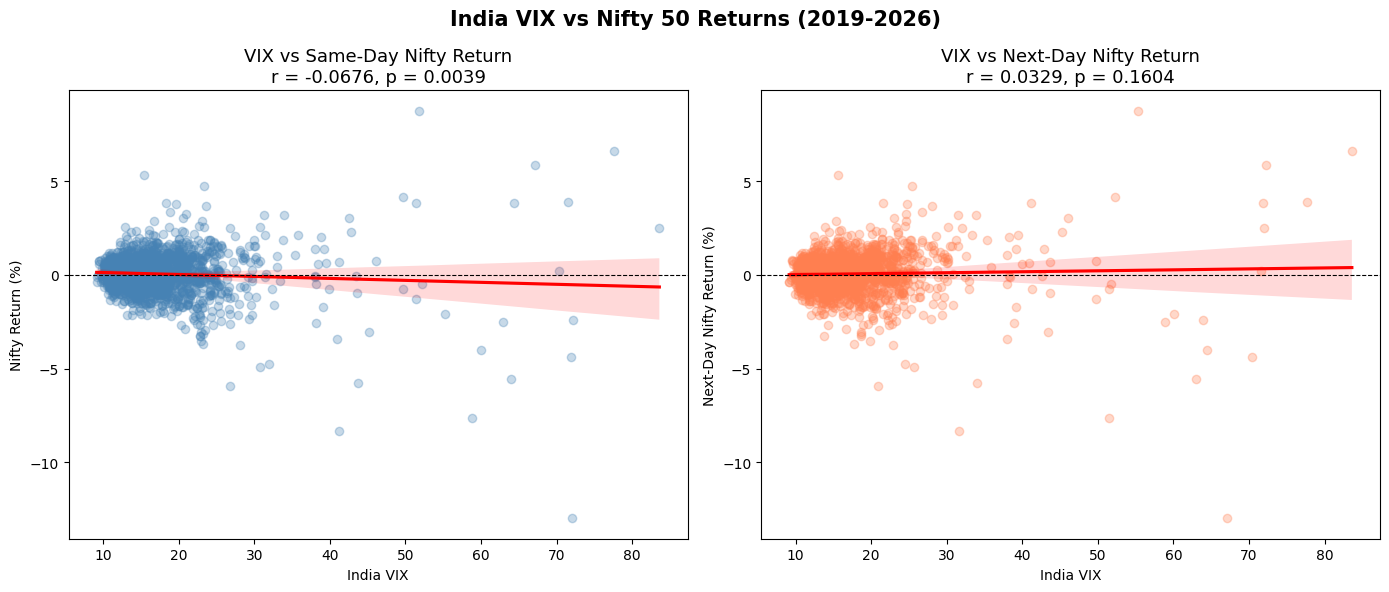

Chart saved.


In [41]:
fig, axes = plt.subplots(1, 2, figsize=(14,6))

# Plot 1: VIX vs Same-Day Return
sns.regplot(x=df["VIX"], y=df["Nifty_Return"],
            ax=axes[0],
            scatter_kws={"alpha": 0.3, "color": "steelblue"},
            line_kws={"color":"red"})
axes[0].set_title(f"VIX vs Same-Day Nifty Return\nr = -0.0676, p = 0.0039", fontsize=13)
axes[0].set_xlabel("India VIX")
axes[0].set_ylabel("Nifty Return (%)")
axes[0].axhline(0, color="black", linewidth=0.8, linestyle="--")

# Plot 2: VIX vs Next-Day Return
sns.regplot(x=df["VIX"], y=df["Nifty_Next_Return"],
            ax=axes[1],
            scatter_kws={"alpha": 0.3, "color":"coral"},
            line_kws={"color": "red"})
axes[1].set_title(f"VIX vs Next-Day Nifty Return\nr = 0.0329, p = 0.1604", fontsize=13)
axes[1].set_xlabel("India VIX")
axes[1].set_ylabel("Next-Day Nifty Return (%)")
axes[1].axhline(0, color="black", linewidth=0.8, linestyle="--")

end_year = pd.Timestamp.today().year
plt.suptitle(f"India VIX vs Nifty 50 Returns (2019-{end_year})", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig("vix_scatter.png", dpi=300, bbox_inches="tight")
plt.show()
print("Chart saved.")

In [42]:
# Define variables
X = df["VIX"]
y = df["Nifty_Next_Return"]

# Add constant (intercept)
X_const = sm.add_constant(X)

# Run OLS regression
model = sm.OLS(y, X_const).fit()

# Print results
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:      Nifty_Next_Return   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                     1.972
Date:                Sun, 28 Jun 2026   Prob (F-statistic):              0.160
Time:                        21:01:40   Log-Likelihood:                -2779.8
No. Observations:                1825   AIC:                             5564.
Df Residuals:                    1823   BIC:                             5575.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0374      0.068     -0.551      0.5

In [43]:
# Create VIX percentile buckets
df["VIX_Bucket"]= pd.qcut(df["VIX"],
                          q=5,
                          labels=["Very Low\n(0-20%)",
                                  "Low\n(20-40%)",
                                  "Medium\n(40-60%)",
                                  "High\n(60-80%)",
                                  "Very High\n(80-100%)"])

#Calculate average next-day return per bucket
bucket_returns= df.groupby("VIX_Bucket", observed=True)["Nifty_Next_Return"].agg(
    Mean_Return="mean",
    Std_Dev="std",
    Count="count"
).reset_index()

print(bucket_returns)

             VIX_Bucket  Mean_Return   Std_Dev  Count
0     Very Low\n(0-20%)     0.040796  0.594221    365
1         Low\n(20-40%)    -0.018277  0.745972    365
2      Medium\n(40-60%)     0.070164  0.830329    366
3        High\n(60-80%)    -0.012994  1.013146    365
4  Very High\n(80-100%)     0.174421  1.881624    364


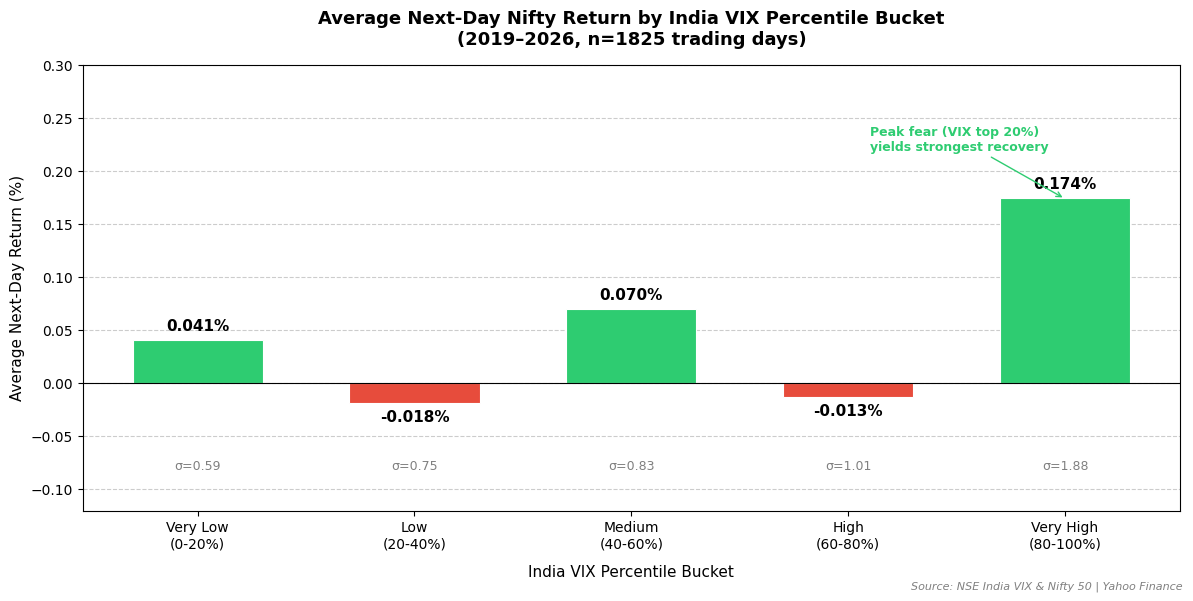

Chart saved.


In [44]:
fig, ax = plt.subplots(figsize=(12, 6))

colors = ["#2ecc71" if x > 0 else "#e74c3c"
          for x in bucket_returns["Mean_Return"]]

bars = ax.bar(bucket_returns["VIX_Bucket"],
              bucket_returns["Mean_Return"],
              color=colors,
              edgecolor="white",
              linewidth=0.8,
              width=0.6)

# Add subtle gridlines
ax.yaxis.grid(True, linestyle="--", alpha=0.4, color="gray")
ax.set_axisbelow(True)

# Add value labels — positive bars above, negative bars below
for bar, val, std in zip(bars,
                          bucket_returns["Mean_Return"],
                          bucket_returns["Std_Dev"]):
    if val >= 0:
        y_pos = bar.get_height() + 0.006
        va = "bottom"
    else:
        y_pos = bar.get_height() - 0.006
        va = "top"

    ax.text(bar.get_x() + bar.get_width()/2,
            y_pos,
            f"{val:.3f}%",
            ha="center", va=va,
            fontsize=11, fontweight="bold",
            color="black")

# Add standard deviation below x-axis labels
for bar, std in zip(bars, bucket_returns["Std_Dev"]):
    ax.text(bar.get_x() + bar.get_width()/2,
            -0.072,
            f"σ={std:.2f}",
            ha="center", va="top",
            fontsize=9, color="gray")

# Key finding annotation
ax.annotate("Peak fear (VIX top 20%)\nyields strongest recovery",
            xy=(4, 0.174),
            xytext=(3.1, 0.22),
            fontsize=9,
            color="#2ecc71",
            arrowprops=dict(arrowstyle="->", color="#2ecc71"),
            fontweight="bold")

ax.axhline(0, color="black", linewidth=0.8)

ax.set_title("Average Next-Day Nifty Return by India VIX Percentile Bucket\n(2019–2026, n=1825 trading days)",
             fontsize=13, fontweight="bold", pad=15)
ax.set_xlabel("India VIX Percentile Bucket", fontsize=11, labelpad=10)
ax.set_ylabel("Average Next-Day Return (%)", fontsize=11)
ax.set_ylim(-0.12, 0.30)

# Source note
fig.text(0.99, 0.01, "Source: NSE India VIX & Nifty 50 | Yahoo Finance",
         ha="right", fontsize=8, color="gray", style="italic")

plt.tight_layout()
plt.savefig("vix_buckets.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved.")